# 02 原型测试

本笔记本进行离线最小训练原型验证，目标是**快速功能验证**而非最终性能报告。

1. **冒烟测试**：验证 `TrajectoryDataHandler`、`DOADataModule`、模型前向传播、卡尔曼滤波器
2. **最小训练原型**：微型模型 2 epoch 端到端训练验证
3. **快速比较实验**：不同轨迹配置的 RMSPE / 运行时间对比
4. **综合结果汇总**：质量门检查，决定是否进入正式训练

### 笔记本规范

- 笔记本用于探索和验证，可重用逻辑应迁移至 `src/`
- 按编号命名以保持长期可维护性
- 所有冒烟测试返回结构化 `StepResult`，便于自动化集成

## 1) 环境设置

初始化路径、随机种子和输出目录。导入顺序确保本地 `src` 优先于 `DCD_MUSIC.src`。

In [28]:
from __future__ import annotations

# STEP 01: 导入标准库，为 notebook 运行做准备
# step 1.1: 所有标准库放在最前面，与项目代码 cell 分离

import copy
import math
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# STEP 02: 解析项目根路径和输出目录
# step 2.1: 从当前目录向上查找，兼容从 notebooks/ 或项目根启动
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# step 2.2: 插入 sys.path，确保 config/ 和 src/ 可导入
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# step 2.3: 将 DCD_MUSIC 子模块路径追加到搜索路径
DCD_ROOT = ROOT / "DCD_MUSIC"
if str(DCD_ROOT) not in sys.path:
    sys.path.append(str(DCD_ROOT))

# step 2.4: 创建图表输出目录，nb2/ 子目录隔离本 notebook 的输出
FIG_DIR = ROOT / "figures" / "nb2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# STEP 03: 配置绘图样式和随机种子，保证输出可复现
plt.rcParams.update({
    "figure.dpi": 150,       # 预览设为 150，保持 notebook 响应流畅
    "axes.grid": True,       # 开启网格线，便于数值读取
    "grid.alpha": 0.3,       # 网格线透明度适中，不遮挡数据
    "grid.linestyle": "--",  # 虚线网格，视觉上更简洁
    "font.size": 10,         # 字体大小适合 notebook 展示
})
np.random.seed(42)
torch.manual_seed(42)

# STEP 04: 检测计算设备和 DCD_MUSIC 子模块完整性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dcd_ok = DCD_ROOT.exists() and any(DCD_ROOT.iterdir())

print(f"Project root : {ROOT}")
print(f"Device       : {device}")
print(f"DCD_MUSIC    : {'OK' if dcd_ok else 'MISSING - run: git submodule update --init --recursive'}")
print(f"Figure output: {FIG_DIR}")

Project root : /Users/lilei/myRepo/SubspaceNet_Update
Device       : cpu
DCD_MUSIC    : OK
Figure output: /Users/lilei/myRepo/SubspaceNet_Update/figures/nb2


## 2) 导入和工具函数

定义：
- `StepResult`：结构化测试结果记录
- `build_fast_config()`：快速配置覆盖（小样本量、短轨迹、少 epoch）
- `format_status_table()`：统一表格报告

In [29]:
# STEP 05: 导入项目模块，定义 notebook 工具类和函数
# step 5.1: 项目模块在标准库之后导入，符合 PEP 8 导入顺序规范

from config.loader import load_config
from config.utils import create_system_model
from src.model_module import SubspaceNetLightning
from src.data_module.trajectory import TrajectoryDataHandler
from src.data_module.lit_datamodule import DOADataModule
from src.eval_module.metrics.rmspe_loss import RMSPELoss


@dataclass
class StepResult:
    """结构化测试结果记录，用于统一收集各冒烟测试的状态信息。

    Attributes:
        name: 测试名称，用于结果表格的标识列
        ok: 测试是否通过
        message: 成功/失败的详细信息
        elapsed_s: 执行耗时，单位秒
    """
    name: str
    ok: bool
    message: str
    elapsed_s: float


def build_fast_config(
    samples_size: int = 48,
    trajectory_length: int = 12,
    batch_size: int = 8,
    epochs: int = 2,
    trajectory_type: str = "random_walk",
    random_walk_std_dev: float = 2.0,
):
    """构建快速验证配置，覆盖耗时参数以加速 notebook 运行。

    Args:
        samples_size: 样本量，缩小以加快 notebook 运行速度
        trajectory_length: 轨迹长度，缩短以减少计算量
        batch_size: 批大小，缩小以适应有限内存
        epochs: 训练轮数，原型验证只需少量轮次
        trajectory_type: 轨迹类型，支持 random_walk 和 static
        random_walk_std_dev: 随机游走标准差，控制角度变化幅度

    Returns:
        已覆盖关键参数的快速验证配置
    """
    cfg = load_config(str(ROOT / "run" / "conf" / "default_config.yaml"))

    # step 5.2: 覆盖数据集参数，禁用保存以避免产生临时文件
    cfg.dataset.samples_size = samples_size
    cfg.dataset.create_data = True
    cfg.dataset.save_dataset = False

    # step 5.3: 覆盖轨迹参数，使用传入的运动模型和标准差
    cfg.trajectory.enabled = True
    cfg.trajectory.trajectory_length = trajectory_length
    cfg.trajectory.trajectory_type = trajectory_type
    cfg.trajectory.random_walk_std_dev = float(random_walk_std_dev)
    cfg.trajectory.save_trajectory = False

    # step 5.4: 覆盖训练参数，缩小批大小和轮数以加快 notebook 运行
    cfg.training.batch_size = batch_size
    cfg.training.epochs = epochs
    cfg.training.learning_rate = 1e-3  # 1e-3 是典型的 Adam 初始学习率

    # step 5.5: 固定信源数为 3，确保各冒烟测试的 batch 维度一致
    cfg.system_model.M = 3
    return cfg


def format_status_table(rows: list[StepResult]) -> pd.DataFrame:
    """将 StepResult 列表格式化为 DataFrame，便于 display() 展示。

    Args:
        rows: 测试结果列表

    Returns:
        可用 display() 展示的格式化表格
    """
    return pd.DataFrame([
        {
            "测试名称": r.name,
            "状态": "PASS" if r.ok else "FAIL",
            "耗时(s)": round(r.elapsed_s, 4),
            "信息": r.message,
        }
        for r in rows
    ])


print(f"运行设备: {device}")


运行设备: cpu


## 3) 冒烟测试 A：TrajectoryDataHandler

验证目标：
- 数据集生成无异常
- 返回的 `TrajectoryDataset` 结构和形状正确
- `__getitem__` 返回 `(X, sources_num, labels)` 三元组

,测试名称,状态,耗时(s),信息
0,TrajectoryDataHandler,PASS,0.2287,"len=48, X=(12, 8, 200) [L,N,T], sources_num_le..."


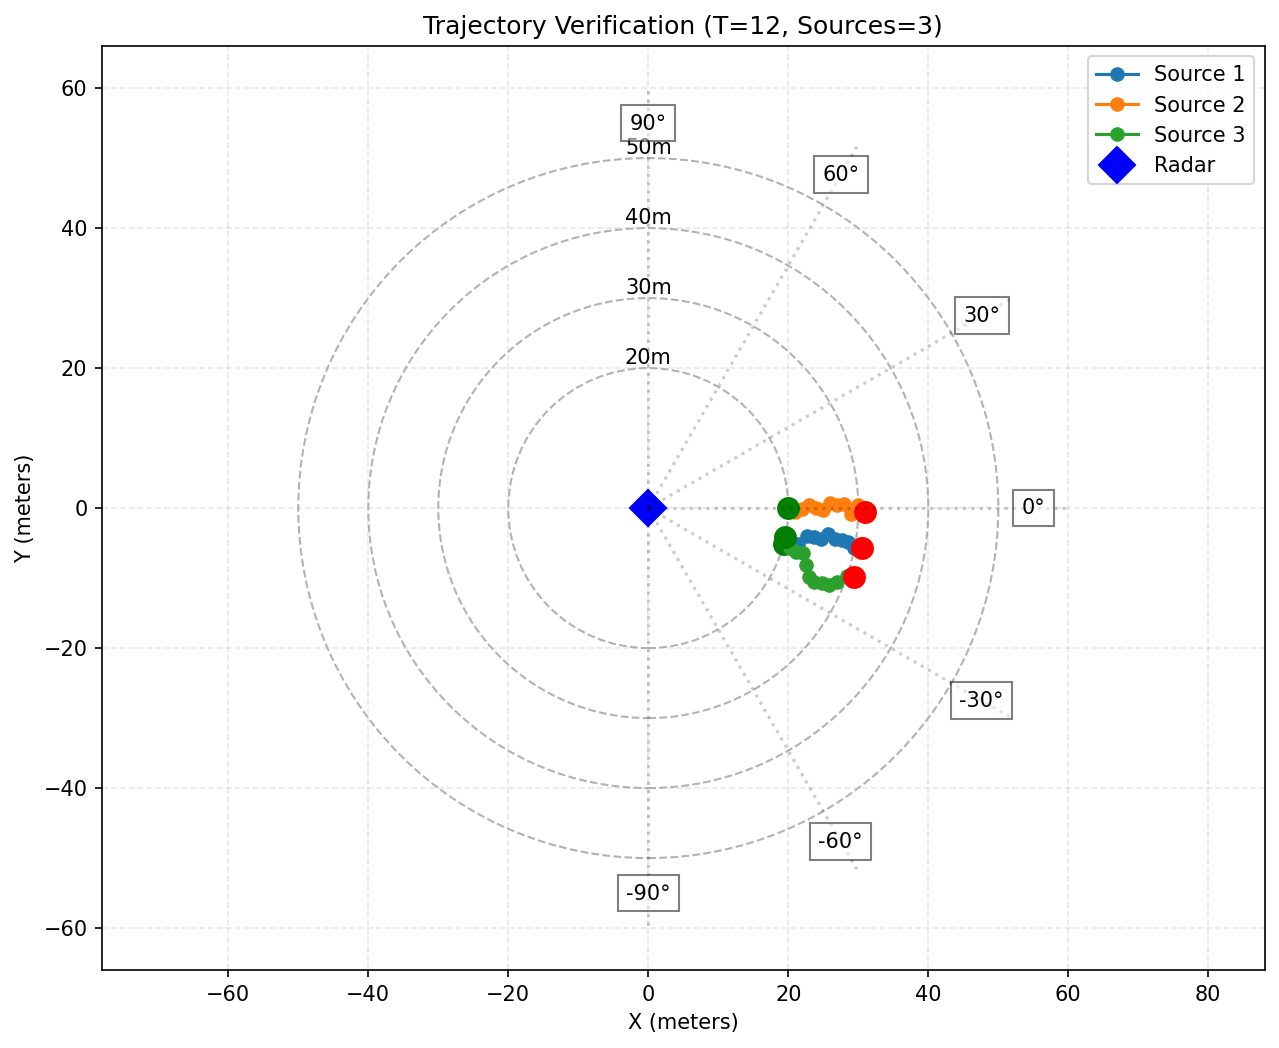

In [30]:
def smoke_test_trajectory_handler(cfg) -> StepResult:
    """验证 TrajectoryDataHandler 能够正确生成数据集。

    Args:
        cfg: 测试配置对象

    Returns:
        StepResult: 包含数据集形状和长度信息的测试结果
    """
    start = time.perf_counter()
    name = "TrajectoryDataHandler"

    # STEP 06: 若子模块缺失则直接跳过，避免后续导入/运行错误
    if not dcd_ok:
        return StepResult(name, False, "SKIP: DCD_MUSIC 子模块缺失", time.perf_counter() - start)

    try:
        # step 6.1: 初始化系统模型和数据处理器
        system_model = create_system_model(cfg)
        handler = TrajectoryDataHandler(system_model_params=system_model.params, config=cfg)
        ds, _ = handler.create_dataset(
            samples_size=cfg.dataset.samples_size,
            trajectory_length=cfg.trajectory.trajectory_length,
            trajectory_type=cfg.trajectory.trajectory_type,
            save_dataset=False,
        )

        # step 6.2: 取第一个样本，验证返回三元组格式
        x0, m0, y0 = ds[0]

        # step 6.3: 断言 L、N、T 维度正确，sources_num 长度与轨迹长度一致
        expected_L = cfg.trajectory.trajectory_length
        expected_N = cfg.system_model.N
        expected_T = cfg.system_model.T
        assert x0.shape[0] == expected_L, f"L 不符: {x0.shape[0]} != {expected_L}"
        assert x0.shape[1] == expected_N, f"N 不符: {x0.shape[1]} != {expected_N}"
        assert x0.shape[2] == expected_T, f"T 不符: {x0.shape[2]} != {expected_T}"
        assert len(m0) == expected_L, f"sources_num 长度不符: {len(m0)} != {expected_L}"

        msg = f"len={len(ds)}, X={tuple(x0.shape)} [L,N,T], sources_num_len={len(m0)}, labels_len={len(y0)}"
        return StepResult(name, True, msg, time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f"{type(exc).__name__}: {exc}", time.perf_counter() - start)


# step 6.4: 使用基础配置执行冒烟测试
cfg_base = build_fast_config()
res_handler = smoke_test_trajectory_handler(cfg_base)
format_status_table([res_handler])


## 4) 冒烟测试 B：DOADataModule

验证目标：
- `setup('fit')` 正确创建 train/val/test 分割
- DataLoader 返回有效批次
- 张量和标签维度对齐

,测试名称,状态,耗时(s),信息
0,DOADataModule,PASS,0.1526,"train=28, val=9, test=11, total=48, batch: X=(..."


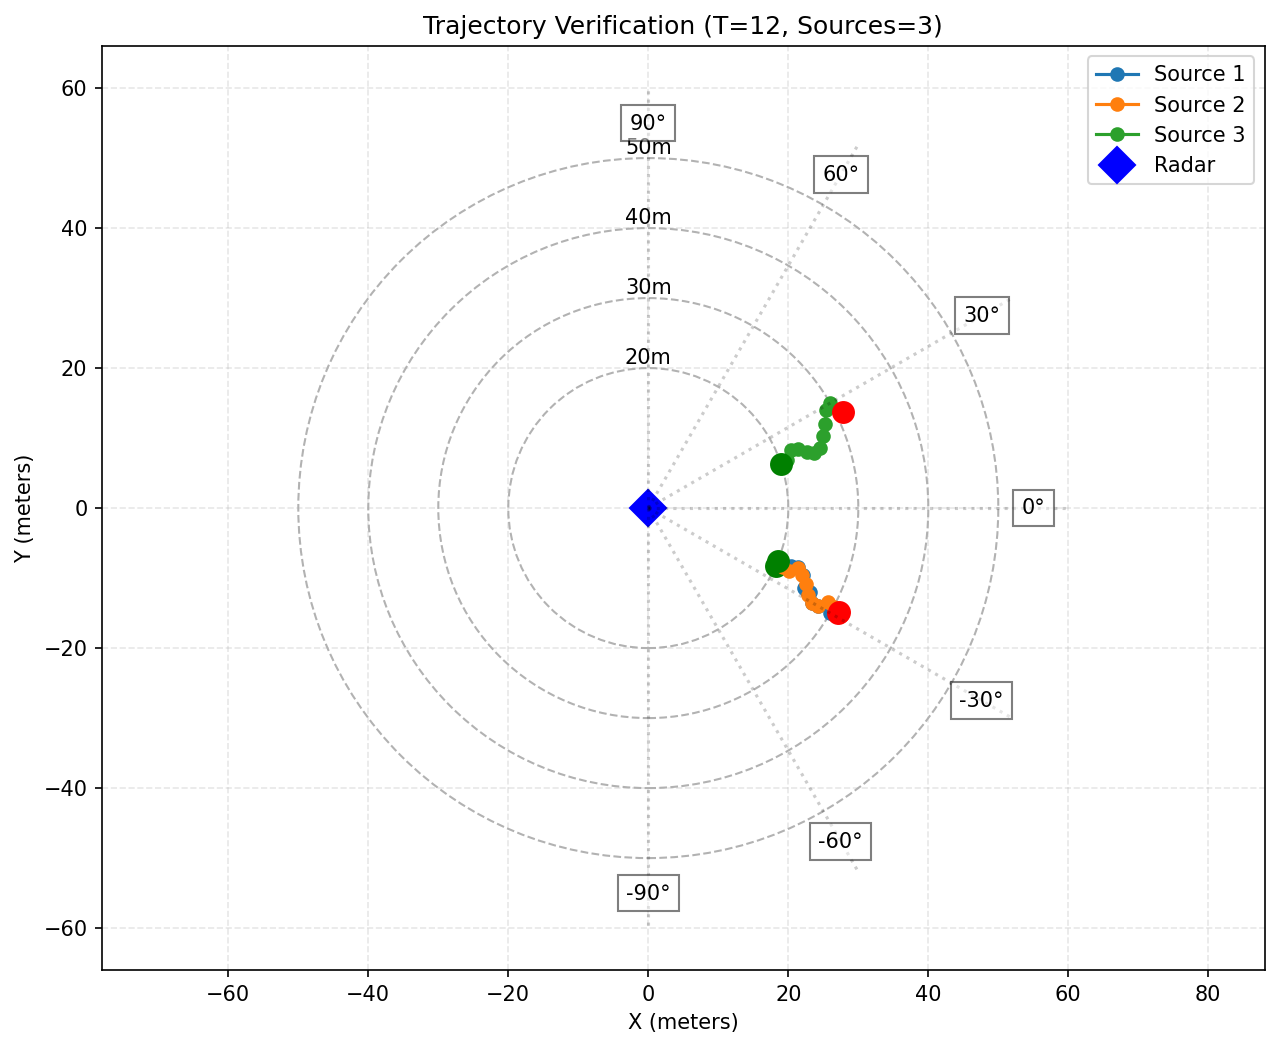

In [31]:
def smoke_test_datamodule(cfg) -> StepResult:
    """验证 DOADataModule 及 DataLoader 行为。

    Args:
        cfg: 测试配置对象

    Returns:
        StepResult: 包含训练集 batch 形状信息的测试结果
    """
    start = time.perf_counter()
    name = "DOADataModule"

    # STEP 07: DataModule 依赖子模块，缺失时直接跳过
    if not dcd_ok:
        return StepResult(name, False, "SKIP: DCD_MUSIC 子模块缺失", time.perf_counter() - start)

    try:
        # step 7.1: 实例化 Lightning DataModule，执行 fit 阶段的 setup
        system_model = create_system_model(cfg)
        dm = DOADataModule(cfg, system_model)
        dm.setup("fit")

        # step 7.2: 验证 split 后三个子集均非空，防止配置比例过小导致空集
        assert len(dm.train_dataset) > 0, "训练集为空"
        assert len(dm.val_dataset) > 0, "验证集为空"
        assert len(dm.test_dataset) > 0, "测试集为空"

        # step 7.3: 从训练集 DataLoader 取第一个 batch，验证张量形状
        total = len(dm.train_dataset) + len(dm.val_dataset) + len(dm.test_dataset)

        train_dl = dm.train_dataloader()
        batch = next(iter(train_dl))
        x, m, y = batch

        msg = (
            f"train={len(dm.train_dataset)}, val={len(dm.val_dataset)}, "
            f"test={len(dm.test_dataset)}, total={total}, "
            f"batch: X={tuple(x.shape)}, M={tuple(m.shape)}, Y={tuple(y.shape)}"
        )
        return StepResult(name, True, msg, time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f"{type(exc).__name__}: {exc}", time.perf_counter() - start)


res_dm = smoke_test_datamodule(cfg_base)
format_status_table([res_dm])


## 5) 冒烟测试 C：模型前向传播

验证目标：
- `SubspaceNetLightning` 实例化成功
- 至少一种前向调用签名正常工作
- 输出格式可用于损失计算

,测试名称,状态,耗时(s),信息
0,SubspaceNet 前向传播,PASS,0.1797,"签名='last step only', output=((8, 3), (8,), ())"


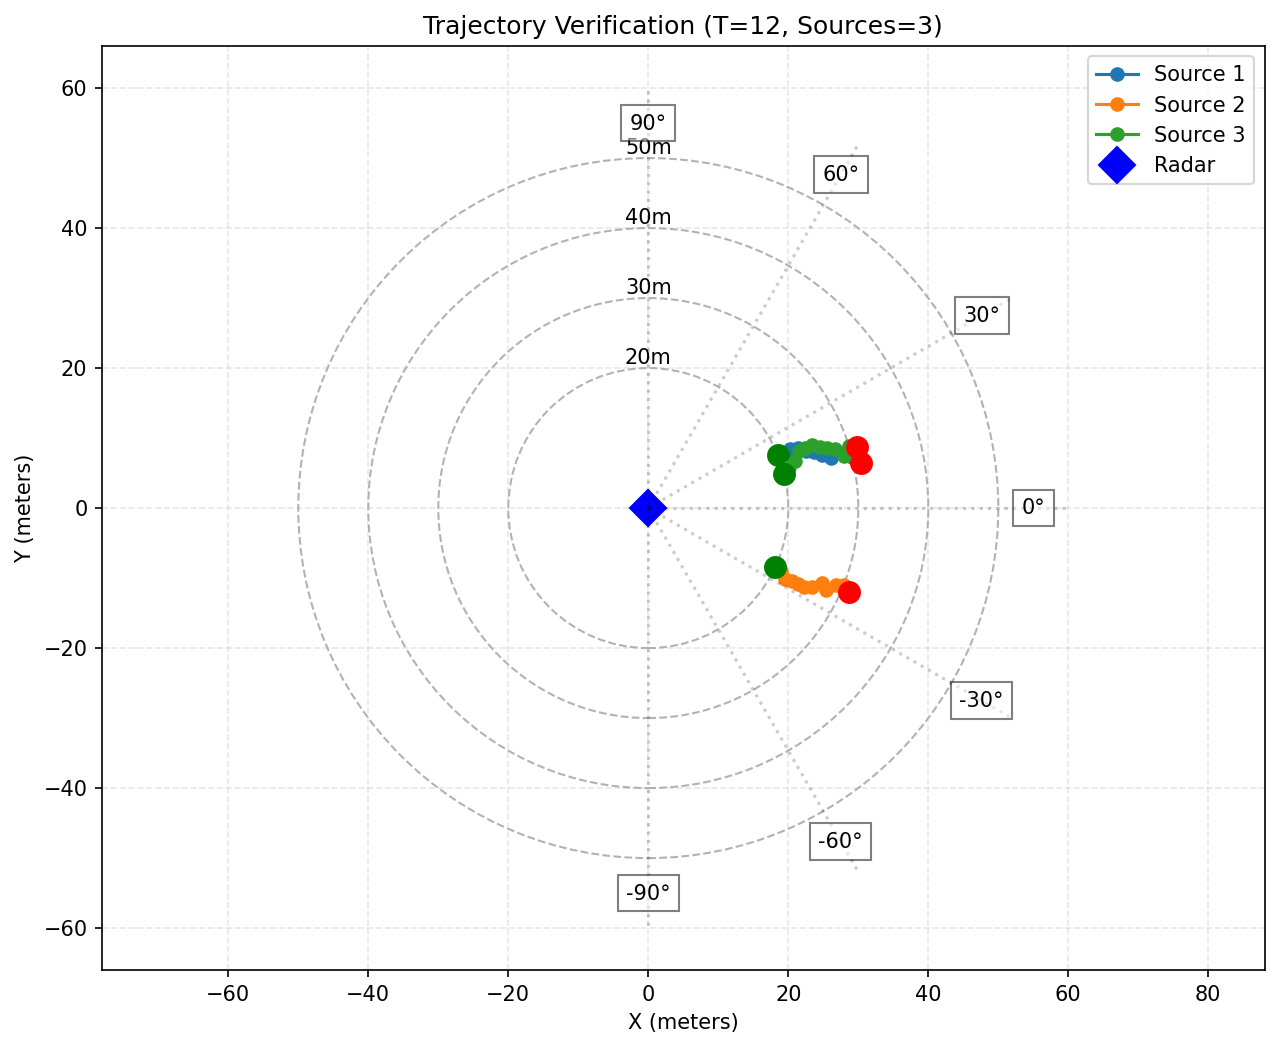

In [32]:
def smoke_test_model_forward(cfg) -> StepResult:
    """验证 SubspaceNetLightning 前向传播。

    Args:
        cfg: 测试配置对象

    Returns:
        StepResult: 包含有效调用签名和输出形状的测试结果
    """
    start = time.perf_counter()
    name = "SubspaceNet 前向传播"

    # STEP 08: 模型前向传播依赖子模块，缺失时直接跳过
    if not dcd_ok:
        return StepResult(name, False, "SKIP: DCD_MUSIC 子模块缺失", time.perf_counter() - start)

    try:
        # step 8.1: 通过 DataModule 获取真实 batch，确保测试与训练时输入一致
        system_model = create_system_model(cfg)
        dm = DOADataModule(cfg, system_model)
        dm.setup("fit")
        x, m, _ = next(iter(dm.train_dataloader()))

        # step 8.2: 实例化模型并移至目标设备（CPU/GPU）
        model = SubspaceNetLightning(system_model=system_model).to(device)
        x = x.to(device)
        m = m.to(device)

        # step 8.3: 依次尝试多种调用签名，找到第一个可用的接口； 这里是防御性，探索coding
        out = None
        last_err = None
        signatures = [
            ("full trajectory", lambda: model(x, m)),
            ("full no m",       lambda: model(x)),
            ("last step + m",   lambda: model(x[:, -1], m[:, -1])),
            ("last step only",  lambda: model(x[:, -1])),
        ]
        used_sig = ""
        for sig_name, call in signatures:
            try:
                out = call()
                used_sig = sig_name
                break
            except Exception as exc:
                last_err = exc

        if out is None:
            raise RuntimeError(f"所有签名均失败; 最后错误: {last_err}")

        # step 8.4: 统一处理 tensor、tuple/list 输出，生成可读的形状描述
        if isinstance(out, (tuple, list)):
            out_desc = ", ".join(
                f"{tuple(t.shape)}" for t in out if hasattr(t, "shape")
            )
        elif hasattr(out, "shape"):
            out_desc = str(tuple(out.shape))
        else:
            out_desc = f"type={type(out).__name__}"

        msg = f"签名='{used_sig}', output=({out_desc})"
        return StepResult(name, True, msg, time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f"{type(exc).__name__}: {exc}", time.perf_counter() - start)


res_fwd = smoke_test_model_forward(cfg_base)
format_status_table([res_fwd])


## 6) 冒烟测试 D：卡尔曼滤波器

验证目标：
- `ExtendedKalmanFilter1D` 实例化和 `predict/update` 循环无异常
- 新息统计量（`innovation`、`Ky`、`y_S_inv_y`）返回值合理
- 这是在线无监督自适应的核心组件

In [33]:
def smoke_test_kalman_filter(cfg) -> StepResult:
    """验证 ExtendedKalmanFilter1D 预测/更新循环。

    Args:
        cfg: 测试配置对象，用于获取信源数量 M

    Returns:
        StepResult: 通过 1D EKF 循环的测试结果
    """
    start = time.perf_counter()
    name = "ExtendedKalmanFilter1D"

    try:
        from simulation.kalman_filter.extended import ExtendedKalmanFilter1D

        M = cfg.system_model.M

        # STEP 09: 每个信源独立一个滤波器，用 create_filters_from_config 批量创建
        filters = ExtendedKalmanFilter1D.create_filters_from_config(cfg, num_instances=M)

        # step 9.1: 用等间隔角度初始化每个滤波器的状态
        init_angles = np.linspace(-20, 20, M)
        for i, kf in enumerate(filters):
            kf.initialize_state(init_angles[i])

        # step 9.2: 运行 10 步预测/更新循环，验证滤波器不崩溃
        innovations = []
        for step in range(10):
            # step 9.3: 生成带噪声的真实角度作为量测值，每步角度匀速增加 0.5°
            true_angles = init_angles + step * 0.5 + np.random.randn(M) * 0.1

            step_innovations = []
            for i, kf in enumerate(filters):
                kf.predict()
                # update 返回 (x_new, innovation, K, K*y, y_s_inv_y, S)
                _, innov, *_ = kf.update(true_angles[i])
                step_innovations.append(float(innov.abs()))

            innovations.append(np.mean(step_innovations))

        msg = (
            f"M={M}, 10步预测/更新完成"
            + f", 平均|innovation|={np.mean(innovations):.4f}"
        )
        return StepResult(name, True, msg, time.perf_counter() - start)
    except ImportError:
        return StepResult(name, False, "SKIP: simulation.kalman_filter 模块缺失", time.perf_counter() - start)
    except Exception as exc:
        return StepResult(name, False, f"{type(exc).__name__}: {exc}", time.perf_counter() - start)


res_kf = smoke_test_kalman_filter(cfg_base)
format_status_table([res_kf])

,测试名称,状态,耗时(s),信息
0,ExtendedKalmanFilter1D,PASS,0.0049,"M=3, 10步预测/更新完成, 平均|innovation|=0.4795"


## 7) 最小离线训练原型

构建一个微型角度回归模型，经过 2 个 epoch 训练，验证优化器、损失计算和运行时日志记录是否端到端正常工作。

状态: OK
最终损失: 0.249408
角度 RMSPE: 14.29°
运行时间: 0.200s
Epoch 损失列表: ['0.2681', '0.2494']


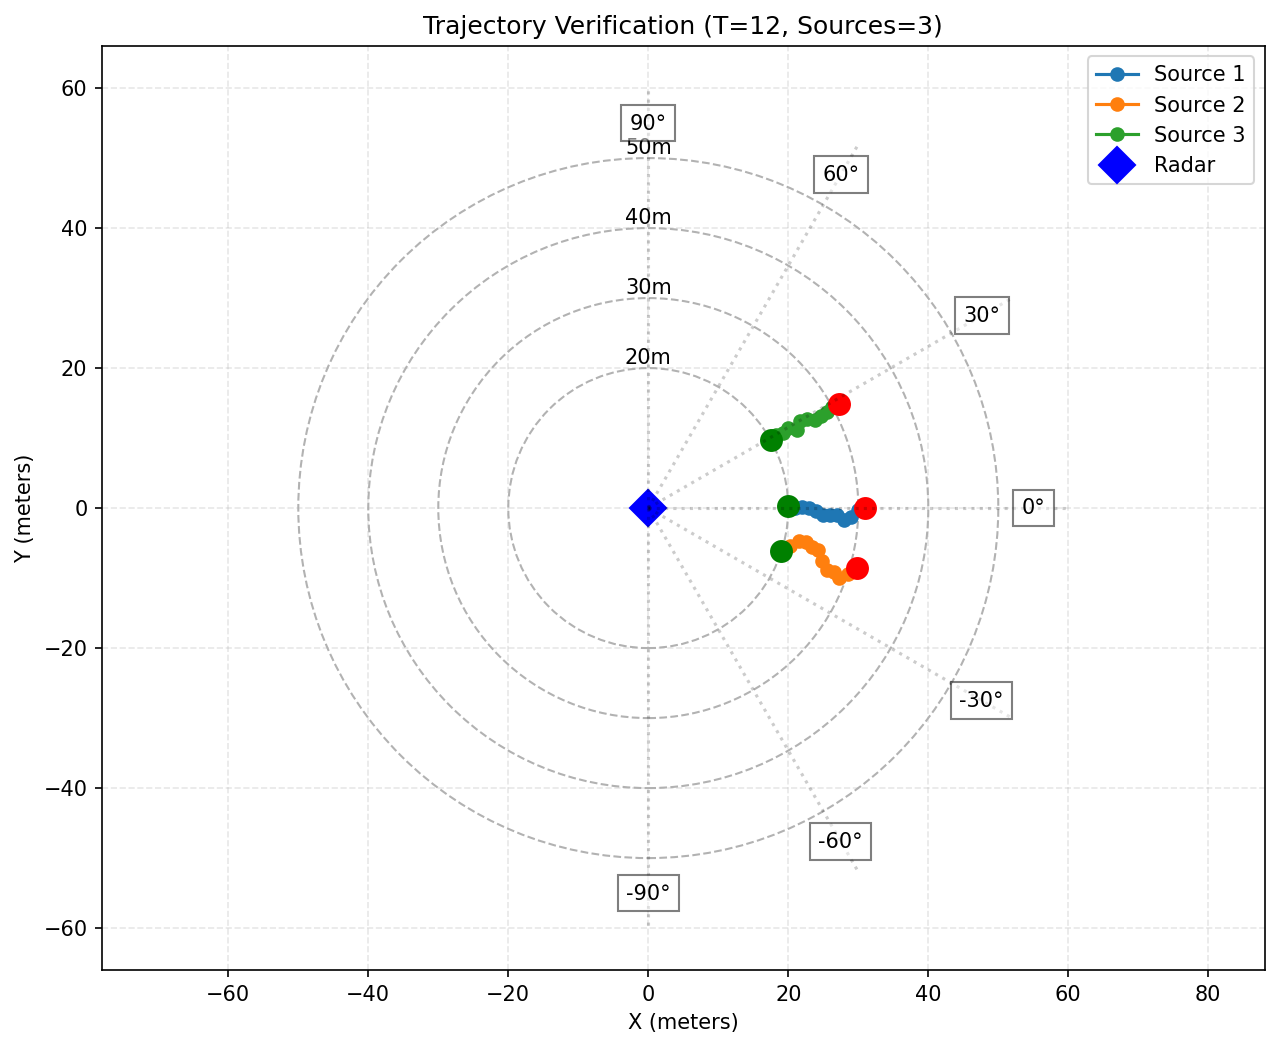

In [34]:
class TinyAngleRegressor(nn.Module):
    """用于验证训练流程的轻量角度回归模型。

    用实部/虚部均值特征替代子空间方法，降低计算成本以快速验证端到端训练流程。
    """

    def __init__(self, n_sensors: int, n_sources: int):
        """构建两层 MLP 网络。

        Args:
            n_sensors: 天线数 N
            n_sources: 估计的信源数量 M
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * n_sensors, 64),  # 2N：拼接实部和虚部均值特征，输入维度为 2N
            nn.ReLU(),
            nn.Linear(64, n_sources),
        )

    def forward(self, x_last_step: torch.Tensor) -> torch.Tensor:
        """从阵列观测矩阵提取特征并预测 DOA 角度。

        Args:
            x_last_step: 当前轨迹最后一步的阵列观测，形状 [B, N, T]

        Returns:
            torch.Tensor: 预测的 DOA 角度，形状 [B, M]
        """
        # STEP 10: 沿快拍维度取实部和虚部的均值，压缩 T 维
        feat_real = x_last_step.real.mean(dim=-1)  # [B, N, T] -> [B, N]
        feat_imag = x_last_step.imag.mean(dim=-1)  # [B, N, T] -> [B, N]

        # step 10.1: 拼接实部和虚部特征，形状变为 [B, 2N]，送入 MLP
        feat = torch.cat([feat_real, feat_imag], dim=-1)
        return self.net(feat)


def run_tiny_prototype(cfg) -> Dict[str, Any]:
    """执行微型离线训练原型，返回最终 RMSPE。

    Args:
        cfg: 测试配置对象

    Returns:
        Dict[str, Any]: 包含训练状态、RMSPE、每 epoch 损失列表的字典
    """
    t0 = time.perf_counter()

    # STEP 11: 若子模块缺失则跳过，返回 NaN 占位以保持结果表格结构完整
    if not dcd_ok:
        return {
            "status": "SKIP", "message": "DCD_MUSIC 子模块缺失",
            "loss": np.nan, "rmspe_deg": np.nan, "runtime_s": time.perf_counter() - t0,
        }

    # step 11.1: 初始化 DataModule，准备训练数据加载器
    system_model = create_system_model(cfg)
    dm = DOADataModule(cfg, system_model)
    dm.setup("fit")

    train_dl = dm.train_dataloader()
    n_sensors = int(cfg.system_model.N)
    n_sources = int(cfg.system_model.M)

    # step 11.2: 初始化模型、Adam 优化器和 RMSPE 损失函数
    model = TinyAngleRegressor(n_sensors=n_sensors, n_sources=n_sources).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.training.learning_rate)
    criterion = RMSPELoss().to(device)

    epoch_losses_history = []

    # step 11.3: 按 epoch 迭代，收集每 epoch 的平均损失
    for epoch in range(cfg.training.epochs):
        model.train()
        epoch_losses = []

        for x, _, y in train_dl:
            x, y = x.to(device), y.to(device)

            # step 11.4: 取轨迹最后一步作为输入，计算预测值和损失
            x_last = x[:, -1]                     # [B, L, N, T] -> [B, N, T]
            y_last = y[:, -1, :n_sources]         # [B, L, *] -> [B, M]

            pred = model(x_last)
            loss = criterion(pred, y_last) / max(1, x_last.size(0))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu()))

        epoch_losses_history.append(np.mean(epoch_losses) if epoch_losses else np.nan)

    # step 11.5: 将最终 loss（弧度单位）乘以 180/π 转换为角度制 RMSPE
    last_loss = epoch_losses_history[-1] if epoch_losses_history else np.nan
    last_rmspe = float(last_loss * 180.0 / math.pi) if not np.isnan(last_loss) else np.nan

    return {
        "status": "OK",
        "message": "训练完成",
        "loss": float(last_loss),
        "rmspe_deg": last_rmspe,
        "epoch_losses": epoch_losses_history,
        "runtime_s": time.perf_counter() - t0,
    }


proto_result = run_tiny_prototype(cfg_base)
print(f"状态: {proto_result['status']}")
print(f"最终损失: {proto_result['loss']:.6f}")
print(f"角度 RMSPE: {proto_result['rmspe_deg']:.2f}°")
print(f"运行时间: {proto_result['runtime_s']:.3f}s")
print(f"Epoch 损失列表: {[f'{v:.4f}' for v in proto_result.get('epoch_losses', [])]}")


## 8) 快速比较实验

通过变更 `trajectory_type` 和 `random_walk_std_dev` 比较不同轨迹配置下的训练效果。

,轨迹类型,游走std,状态,损失,RMSPE [°],运行时 [s]
0,random_walk,1.0,OK,0.203176,11.64,0.985
1,random_walk,3.0,OK,0.235872,13.51,0.130
2,random_walk,5.0,OK,0.263451,15.09,0.130
3,static,1.0,OK,0.248499,14.24,0.122


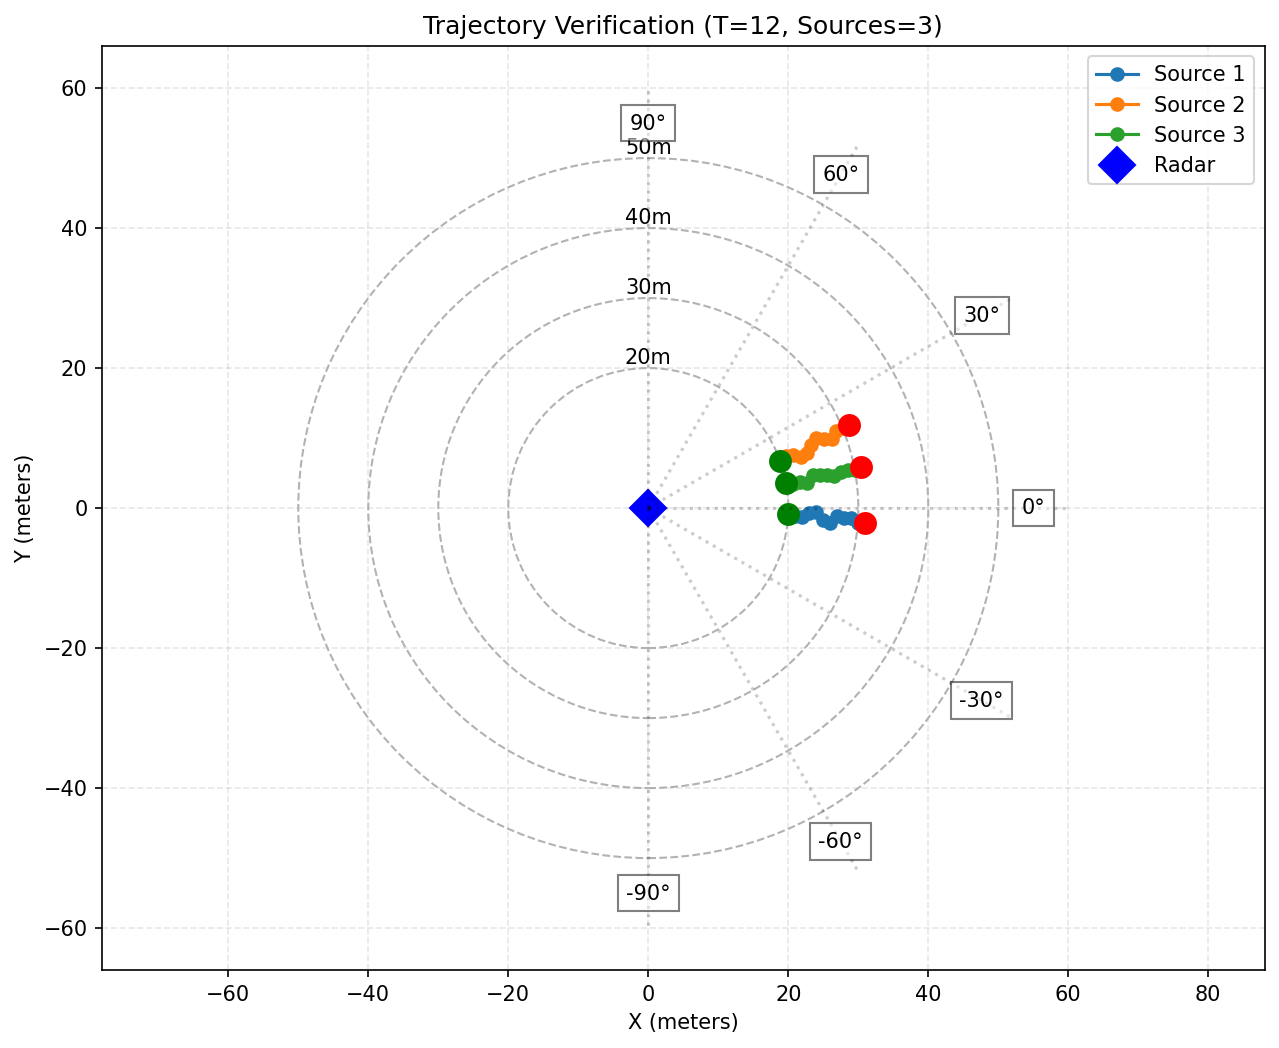

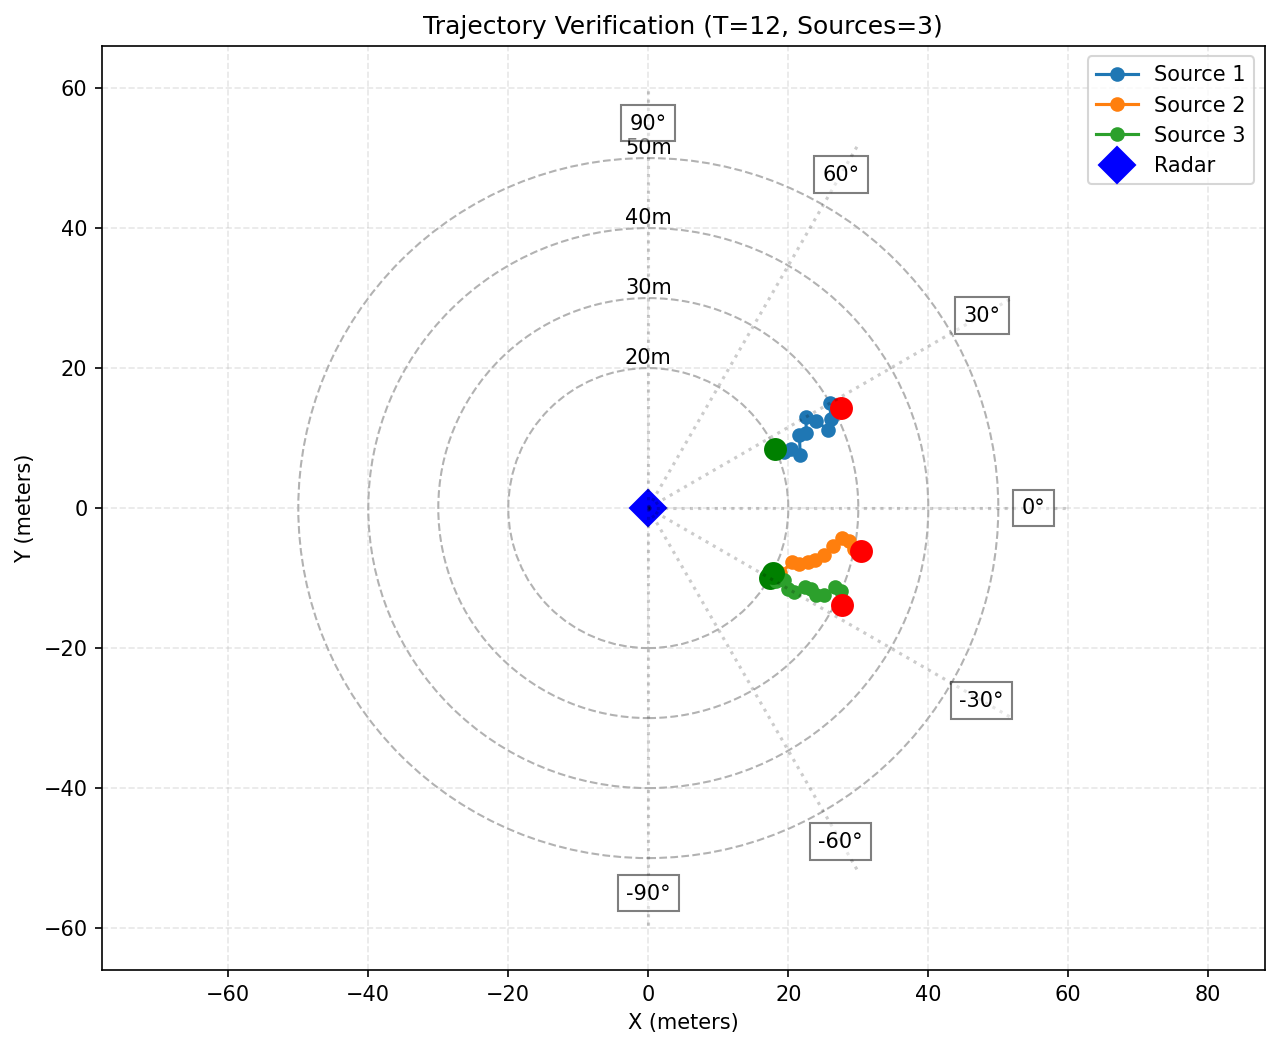

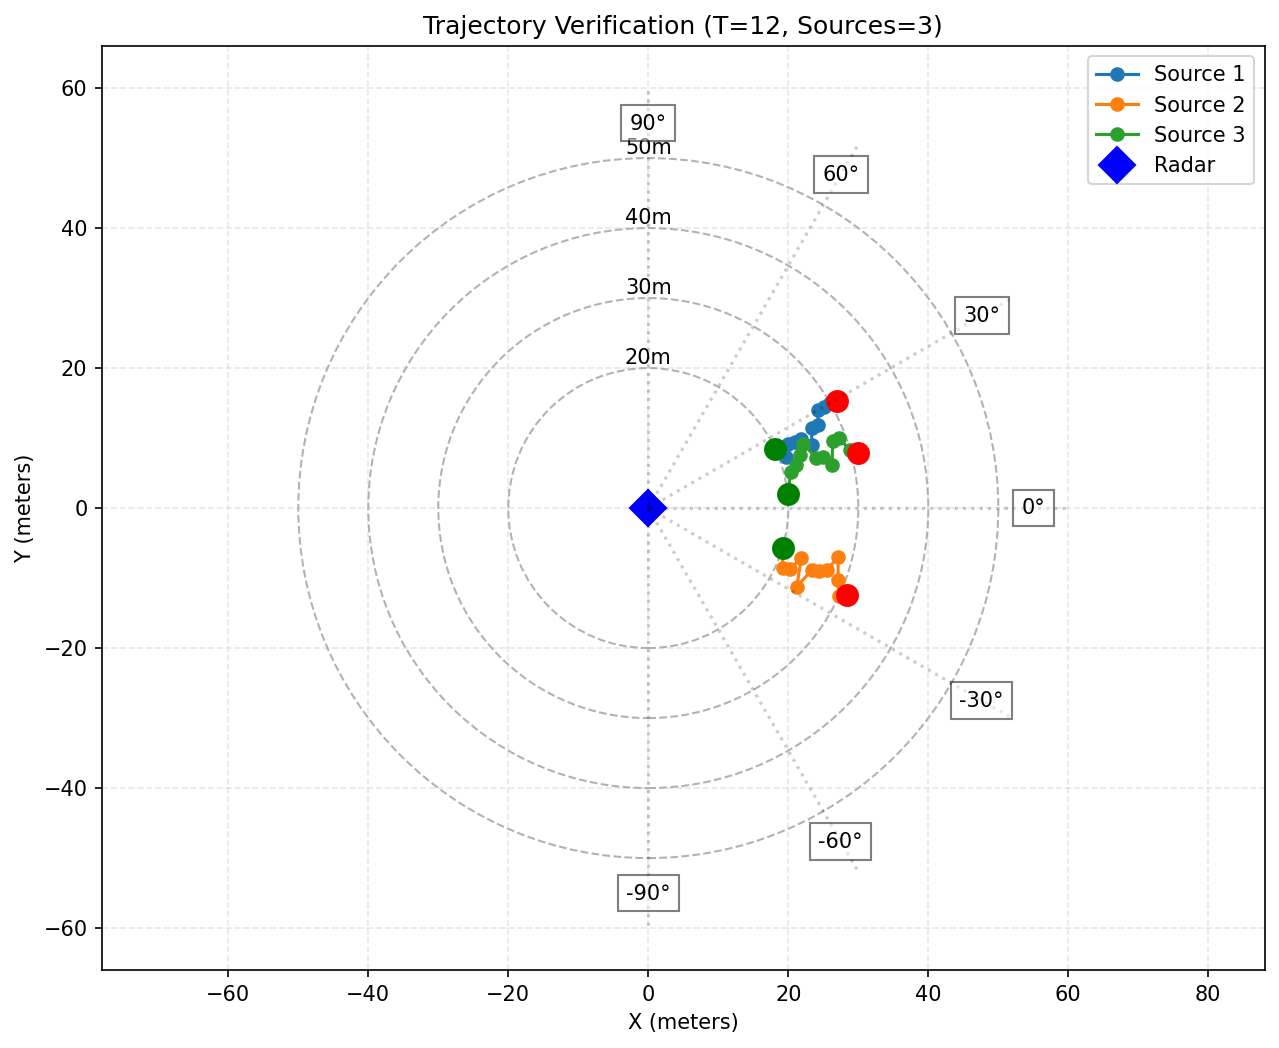

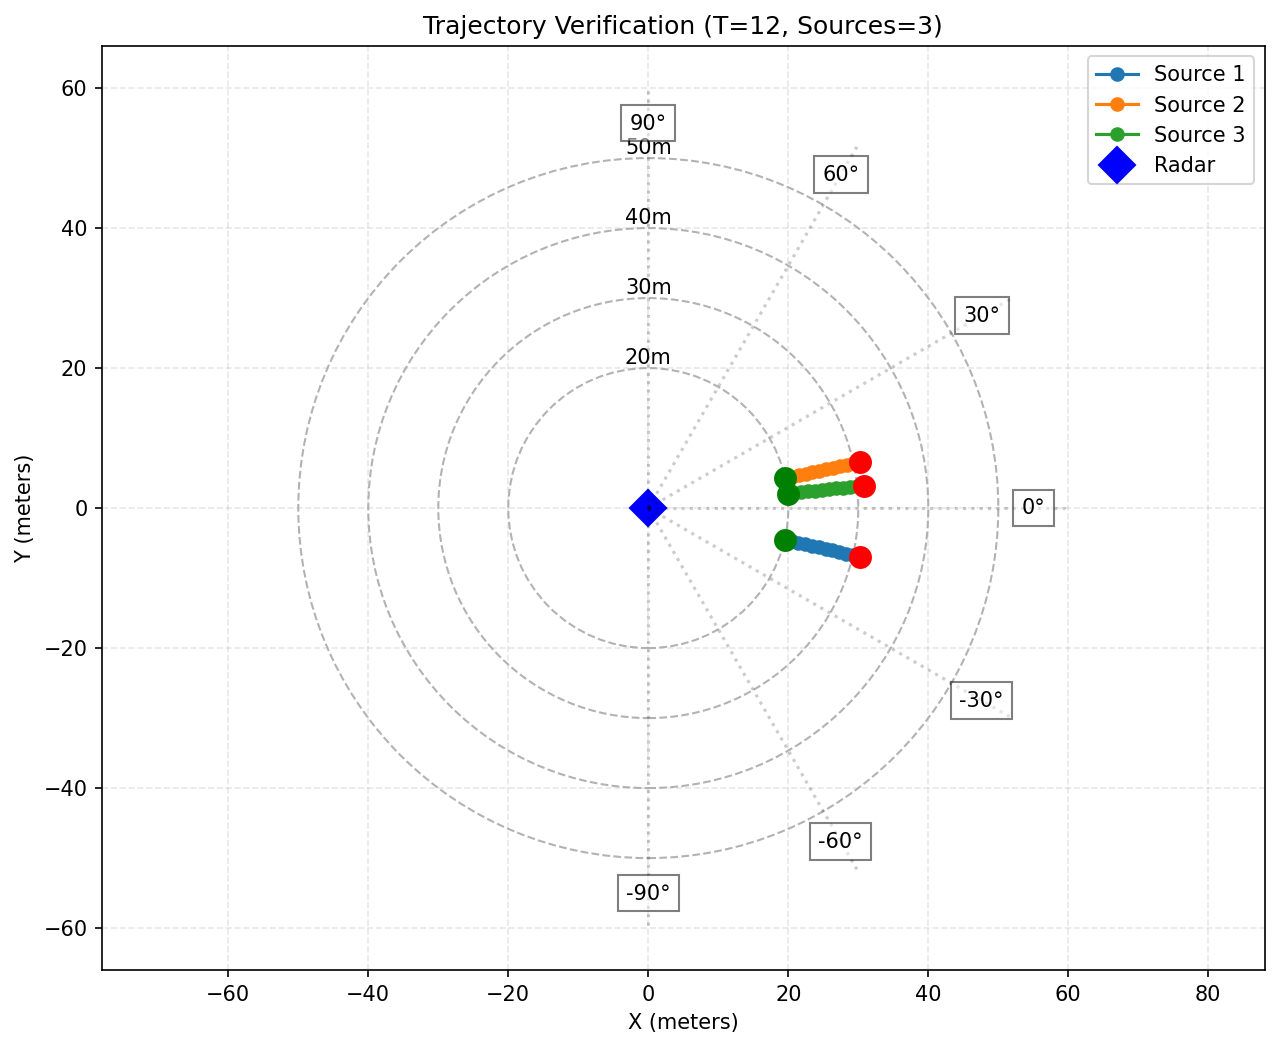

In [35]:
# STEP 12: 定义对比实验配置，覆盖不同轨迹类型和运动幅度
settings = [
    {"trajectory_type": "random_walk", "random_walk_std_dev": 1.0},
    {"trajectory_type": "random_walk", "random_walk_std_dev": 3.0},
    {"trajectory_type": "random_walk", "random_walk_std_dev": 5.0},
    {"trajectory_type": "static",      "random_walk_std_dev": 1.0},
]

rows = []
for s in settings:
    # step 12.1: 为每组配置构建快速验证 config 并执行微型训练
    cfg = build_fast_config(
        samples_size=48, trajectory_length=12, batch_size=8, epochs=2,
        trajectory_type=s["trajectory_type"],
        random_walk_std_dev=s["random_walk_std_dev"],
    )
    out = run_tiny_prototype(cfg)
    rows.append({
        "轨迹类型": s["trajectory_type"],
        "游走std": s["random_walk_std_dev"],
        "状态": out["status"],
        "损失": round(out["loss"], 6) if not np.isnan(out["loss"]) else "N/A",
        "RMSPE [°]": round(out["rmspe_deg"], 2) if not np.isnan(out["rmspe_deg"]) else "N/A",
        "运行时 [s]": round(out["runtime_s"], 3),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df)


### 8a) RMSPE 对比柱状图 + 帕累托前沿

左图：不同配置的 RMSPE 对比（越低越好）
右图：运行时间 vs RMSPE 的帕累托前沿，标识最优权衡点

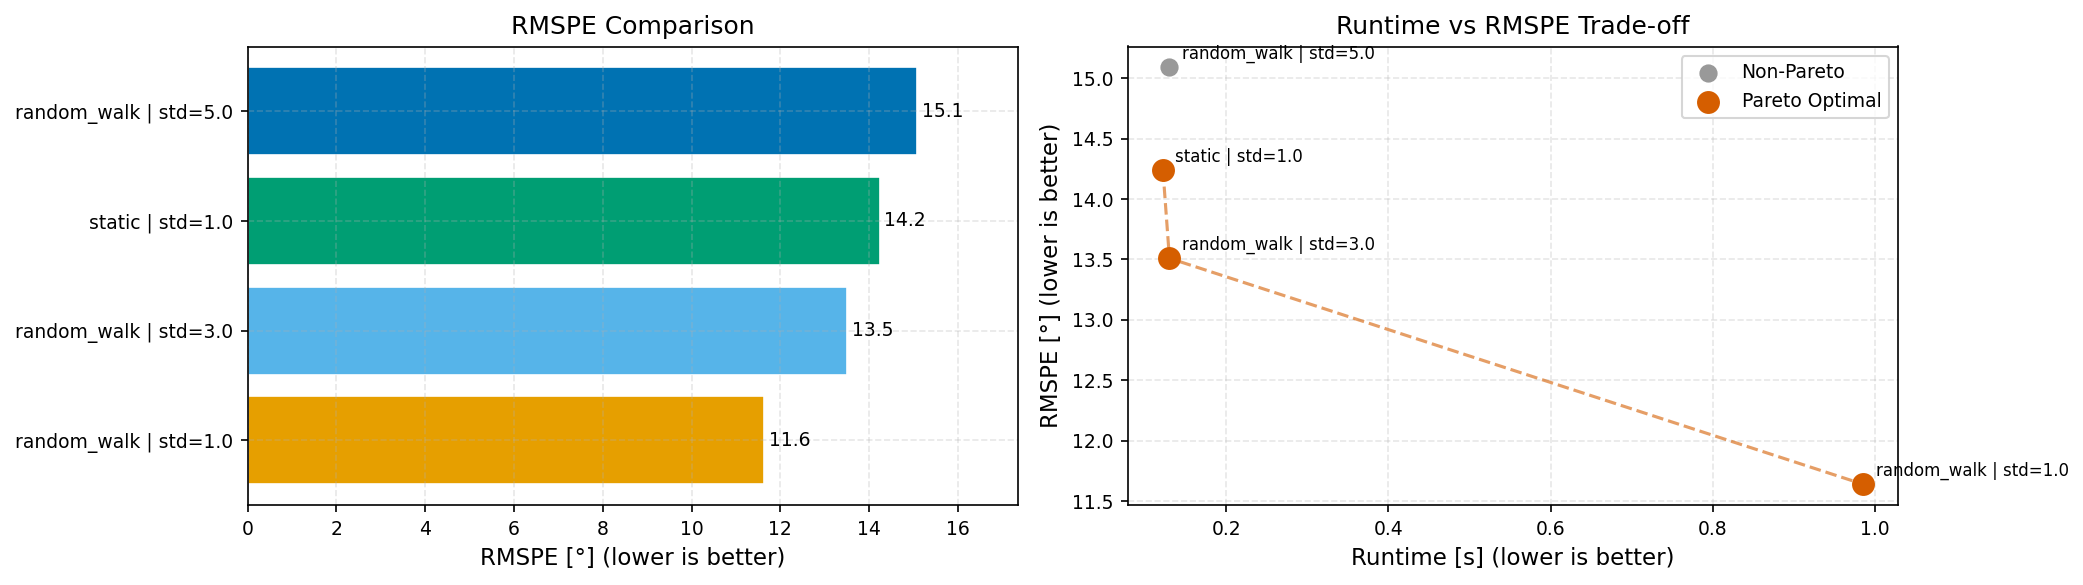

In [36]:
# STEP 13: Plot comparison results — RMSPE bar chart + Pareto front
# Okabe-Ito colorblind-friendly palette
OI = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442", "#000000"]

# step 13.1: Convert string values to float, drop invalid rows
plot_df = comparison_df.copy()
plot_df["RMSPE_val"]   = pd.to_numeric(plot_df["RMSPE [°]"],   errors="coerce")
plot_df["runtime_val"] = pd.to_numeric(plot_df["运行时 [s]"],  errors="coerce")
plot_df = plot_df.dropna(subset=["RMSPE_val", "runtime_val"])
plot_df["label"] = plot_df.apply(
    lambda r: f"{r['轨迹类型']} | std={r['游走std']}", axis=1
)
plot_df = plot_df.sort_values("RMSPE_val", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# step 13.2: Horizontal bar chart sorted by RMSPE ascending
colors = OI[:len(plot_df)]
bars = ax1.barh(plot_df["label"], plot_df["RMSPE_val"],
                color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, plot_df["RMSPE_val"]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", fontsize=9)
ax1.set_xlabel("RMSPE [°] (lower is better)", fontsize=11)
ax1.set_title("RMSPE Comparison", fontsize=12)
ax1.tick_params(labelsize=9)
ax1.set_xlim(0, plot_df["RMSPE_val"].max() * 1.15)

# step 13.3: Compute Pareto front (runtime vs RMSPE)
X = plot_df["runtime_val"].to_numpy()
Y = plot_df["RMSPE_val"].to_numpy()

is_pareto = np.ones(len(plot_df), dtype=bool)
for i in range(len(plot_df)):
    for j in range(len(plot_df)):
        if i != j and X[j] <= X[i] and Y[j] <= Y[i] and (X[j] < X[i] or Y[j] < Y[i]):
            is_pareto[i] = False
            break

ax2.scatter(X[~is_pareto], Y[~is_pareto], color="#999999", s=60, label="Non-Pareto", zorder=3)
ax2.scatter(X[is_pareto],  Y[is_pareto],  color=OI[4],    s=100, label="Pareto Optimal", zorder=5)

for _, r in plot_df.iterrows():
    ax2.annotate(r["label"], (r["runtime_val"], r["RMSPE_val"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)

frontier = plot_df.iloc[np.where(is_pareto)[0]].sort_values("runtime_val")
if len(frontier) >= 2:
    ax2.plot(frontier["runtime_val"], frontier["RMSPE_val"],
             color=OI[4], linewidth=1.5, alpha=0.6, linestyle="--")

ax2.set_xlabel("Runtime [s] (lower is better)", fontsize=11)
ax2.set_ylabel("RMSPE [°] (lower is better)", fontsize=11)
ax2.set_title("Runtime vs RMSPE Trade-off", fontsize=12)
ax2.tick_params(labelsize=9)
ax2.legend(loc="best", fontsize=9)

fig.tight_layout()
# Save as PDF (vector) for paper quality; also PNG preview at 300 DPI
fig.savefig(FIG_DIR / "prototype_comparison.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "prototype_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 9) 综合结果汇总

合并所有冒烟测试状态和原型指标，形成单一质量门判断。

In [37]:
# STEP 14: 汇总所有冒烟测试结果，作为 notebook 质量门
all_results = [res_handler, res_dm, res_fwd, res_kf]
smoke_df = format_status_table(all_results)

print("=== 冒烟测试汇总 ===")
display(smoke_df)

# step 14.1: 检查所有测试是否通过，计算总耗时，输出最终判断
all_pass = all(r.ok for r in all_results)
total_time = sum(r.elapsed_s for r in all_results)

print(f"\n总耗时: {total_time:.3f}s")
if all_pass:
    print("结论: PASS - 所有冒烟测试通过，可进入正式训练")
else:
    failed = [r.name for r in all_results if not r.ok]
    print(f"结论: FAIL - 未通过测试: {', '.join(failed)}")


=== 冒烟测试汇总 ===


,测试名称,状态,耗时(s),信息
0,TrajectoryDataHandler,PASS,0.2287,"len=48, X=(12, 8, 200) [L,N,T], sources_num_le..."
1,DOADataModule,PASS,0.1526,"train=28, val=9, test=11, total=48, batch: X=(..."
2,SubspaceNet 前向传播,PASS,0.1797,"签名='last step only', output=((8, 3), (8,), ())"
3,ExtendedKalmanFilter1D,PASS,0.0049,"M=3, 10步预测/更新完成, 平均|innovation|=0.4795"



总耗时: 0.566s
结论: PASS - 所有冒烟测试通过，可进入正式训练


### 实验日志推荐字段

在正式运行中保持以下字段稳定，便于后续分析对比：

| 字段 | 说明 |
| ---- | ---- |
| `trajectory_type` | 轨迹运动模型 |
| `random_walk_std_dev` | 随机游走标准差 |
| `loss` | 训练损失 |
| `rmspe_deg` | RMSPE（度） |
| `runtime_s` | 运行时间 |
| `status` | 运行状态 |

In [38]:
# STEP 15: 按 RMSPE 升序排列对比结果，便于快速定位最优配置
# step 15.1: 直接排序展示 comparison_df，无需额外处理
display(comparison_df.sort_values("RMSPE [°]", ascending=True))


,轨迹类型,游走std,状态,损失,RMSPE [°],运行时 [s]
0,random_walk,1.0,OK,0.203176,11.64,0.985
1,random_walk,3.0,OK,0.235872,13.51,0.130
3,static,1.0,OK,0.248499,14.24,0.122
2,random_walk,5.0,OK,0.263451,15.09,0.130


## 10) 导出与下一步

列出导出的图表，提供后续步骤建议。

In [39]:
exported = sorted([p.name for p in FIG_DIR.glob("*.png")])
print(f"导出 {len(exported)} 张图表到 {FIG_DIR}：")
for name in exported:
    print(f"  ├── {name}")

print(f"\n=== 原型验证完成 ===")
print(f"  冒烟测试: {sum(r.ok for r in all_results)}/{len(all_results)} 通过")
print(f"  原型训练: {proto_result['status']}, RMSPE={proto_result['rmspe_deg']:.1f}°")
print(f"  对比实验: {len(comparison_df)} 组配置已测试")

print("\n后续步骤：")
print("  1. 将冒烟测试迁移至 tests/ 目录（pytest 自动化）")
print("  2. 用 SubspaceNetLightning 替换 TinyAngleRegressor 进行正式训练")
print("  3. 启用在线学习流水线（OnlineLearningPipeline）验证自适应能力")
print("  4. 扩大超参数网格搜索（SNR、eta、轨迹类型）")

导出 1 张图表到 /Users/lilei/myRepo/SubspaceNet_Update/figures/nb2：
  ├── prototype_comparison.png

=== 原型验证完成 ===
  冒烟测试: 4/4 通过
  原型训练: OK, RMSPE=14.3°
  对比实验: 4 组配置已测试

后续步骤：
  1. 将冒烟测试迁移至 tests/ 目录（pytest 自动化）
  2. 用 SubspaceNetLightning 替换 TinyAngleRegressor 进行正式训练
  3. 启用在线学习流水线（OnlineLearningPipeline）验证自适应能力
  4. 扩大超参数网格搜索（SNR、eta、轨迹类型）
